## Problem 2: Multinomial Processing Tree example

I implemented 1-high threshold (1HT) and 2-high threshold (2HT) models in Stan. Each model takes in:
- the number of old words in the test wordlist (`N_old`=50)
- the number of new words in the test wordlist (`N_new`=50)
- The number of correct identifications of old words in the test wordlist (`old_ans`)
- The number of new words misidentified as old in the test wordlist (`new_ans`)

The parameters for both models are:
- The 'decision probability' `d`: the probability of immediately identifying old words as old (and in 2HT, the probability of immediately identifying new words as new)
- The 'guess probability' `g`: the probability of guessing a forgotten word is old (in 1HT, all new words are guessed)

For both models, I chose a uniform prior for `d` and `g`: $d,g\sim\operatorname{Beta}(1,1)$

1HT:
- The true positive probability (probability of identifying old words as old): $\verb|p_true_old|=d+(1-d)g$
- The false positive probability (probability of identifying new words as old): $\verb|p_false_old|=g$

2HT:
- The true positive probability (probability of identifying old words as old): $\verb|p_true_old|=d+(1-d)g$
- The false positive probability (probability of identifying new words as old): $\verb|p_false_old|=(1-d)g$

I didn't think that the original data from the slides $N_{old}=N_{new}=10$ would be enough to to any meaningful inference, so I generated more data by writing a Python program to run more tests on a subject (one of my friends). The code picks 20 words from a list of common English nouns (from https://github.com/david47k/top-english-wordlists), creates a second wordlist with 10 original words (shuffled) and 10 new words, and has the user input if each element in the new list is from the old list. This process is repeated 5 times to generate a set of 100 responses, with 50 old items and 50 new items. This notebook reads the output of this program and converts it to `old_ans` and `new_ans` values for each trial.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

In [192]:
model_1ht = CmdStanModel(
    stan_file="models/processing_tree_1high.stan"
)
model_2ht = CmdStanModel(
    stan_file="models/processing_tree_2high.stan"
)

In [226]:
original_words = []
with open("data/original_wordlist_2.txt") as file:
    text=file.read()
    original_words = [[word.strip() for word in line.strip().removesuffix(",").split(",")] for line in text.splitlines()]

subject_responses = []
with open("data/subject_responses_2.txt") as file:
    text=file.read()
    subject_responses = [[(word.strip().split(":")[0],word.strip().split(":")[1]=="YES") for word in line.strip().removesuffix(",").split(",")[:]] for line in text.splitlines()]


In [227]:
N_trials=5

# Same values for all 5 trials I did
# Number of old words in the test wordlist
N_old = 10
# Number of new words in the test wordlist
N_new = 10

# Number of correctly identified old words in the subject's response
old_answers = []
# Number of misidentified new words
new_answers = []

for n in range(N_trials):
    old_answers.append(0)
    new_answers.append(0)
    for word,is_response_old in subject_responses[n]:
        if is_response_old:
            if word in original_words[n]:
                old_answers[-1]+=1
            else:
                new_answers[-1]+=1

# Combination of all trials
N_old_total=N_old*N_trials
N_new_total=N_new*N_trials

old_answers_total=sum(old_answers)
new_answers_total=sum(new_answers)
print(f"N_old = {N_old_total}, N_new = {N_new_total}")
print(f"old_answers = {old_answers_total}, new_answers = {new_answers_total}")

# data_dict={
#     "N_old":N_old_total,
#     "N_new":N_new_total,
#     "old_ans":old_answers_total,
#     "new_ans":new_answers_total
# }
data_dict={
    "N_old":N_old,
    "N_new":N_new,
    "N_trials":5,
    "old_ans":np.array(old_answers,dtype=int),
    "new_ans":np.array(new_answers,dtype=int)
}

N_old = 50, N_new = 50
old_answers = 35, new_answers = 4


In [228]:
NUM_CHAINS = 4
SAMPLING_ITERS = 5_000

fit_1ht = model_1ht.sample(
    data=data_dict, 
    chains=NUM_CHAINS, 
    iter_warmup=500, 
    iter_sampling=SAMPLING_ITERS,
)
fit_2ht = model_2ht.sample(
    data=data_dict, 
    chains=NUM_CHAINS, 
    iter_warmup=500, 
    iter_sampling=SAMPLING_ITERS,
)

04:48:23 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

...

chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

04:48:24 - cmdstanpy - INFO - CmdStan done processing.


In [229]:
summary_1ht=fit_1ht.summary()
summary_2ht=fit_2ht.summary()

print("\n1-high threshold model:")
display(summary_1ht)

print("\n2-high threshold model:")
display(summary_2ht)



1-high threshold model:


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-17.220700,0.010788,1.019880,0.727130,-19.257100,-16.906600,-16.249600,9629.98,10965.5,9525.2,0.999960
d,0.657204,0.000640,0.072694,0.073261,0.531652,0.660803,0.770758,12984.40,12090.8,12843.1,1.000250
g,0.098843,0.000351,0.041281,0.040132,0.040613,0.093794,0.174427,13116.30,11117.1,12973.6,0.999921
p_true_old,0.691785,0.000527,0.063503,0.064754,0.582834,0.694795,0.791745,14486.60,13460.4,14329.0,1.000220
p_false_old,0.098843,0.000351,0.041281,0.040132,0.040613,0.093794,0.174427,13116.30,11117.1,12973.6,0.999921
pred_ans[1],6.941050,0.011331,1.570450,1.482600,4.000000,7.000000,9.000000,19212.20,19059.2,19003.2,1.000130
pred_ans[2],0.992200,0.007489,1.028250,1.482600,0.000000,1.000000,3.000000,18832.70,18872.0,18627.8,0.999934



2-high threshold model:


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-16.408800,0.010987,1.028720,0.749904,-18.430400,-16.099100,-15.424300,9184.46,11884.7,11581.9,1.000440
d,0.609425,0.000578,0.075321,0.075839,0.478576,0.612765,0.728315,17182.70,13330.3,21667.9,1.000120
g,0.234753,0.000698,0.084362,0.084620,0.107541,0.227538,0.385312,14023.70,11501.9,17684.4,0.999947
p_true_old,0.701670,0.000471,0.063617,0.064747,0.593200,0.704202,0.802247,18151.50,13563.2,22889.6,1.000410
p_false_old,0.092245,0.000331,0.039412,0.038030,0.037794,0.086679,0.165309,13669.30,11562.3,17237.4,0.999969
pred_ans[1],7.010700,0.011057,1.559140,1.482600,4.000000,7.000000,9.000000,19966.90,19700.2,25179.0,1.000010
pred_ans[2],0.925450,0.007263,0.994405,1.482600,0.000000,1.000000,3.000000,18806.80,19426.8,23716.0,1.000040


$\hat{R}$ and ESS are good for 1HT and 2HT models.

In [230]:
print("1HT:")
print(fit_1ht.diagnose())
print("="*80+"\n")
print("2HT:")
print(fit_2ht.diagnose())

1HT:
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


2HT:
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Diagnostic plots

#### 1HT

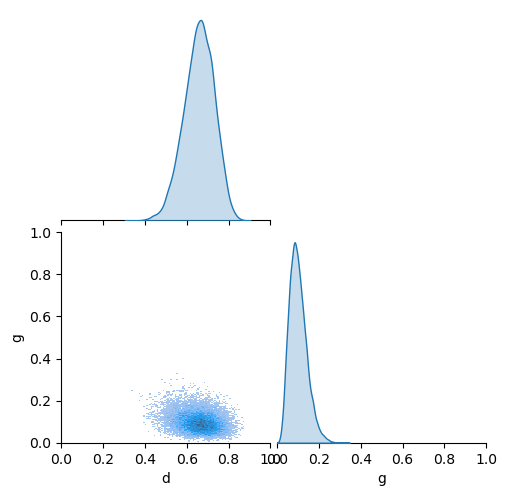

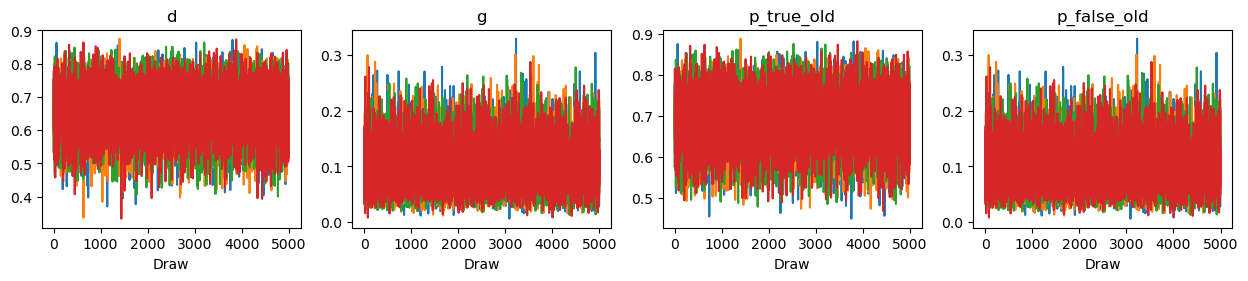

In [231]:
idata_1ht = az.from_cmdstanpy(
    posterior=fit_1ht,
    posterior_predictive="pred_ans",
    observed_data={"old_ans": data_dict["old_ans"],"new_ans": data_dict["new_ans"]},
)
g=sns.pairplot(
    fit_1ht.draws_pd(),vars=["d","g"],
    kind="hist",diag_kind="kde",corner=True
)
g.set(xlim=[0,1])
g.axes[1,0].set_ylim(0,1)
az.plot_trace(idata_1ht)

#### 2HT

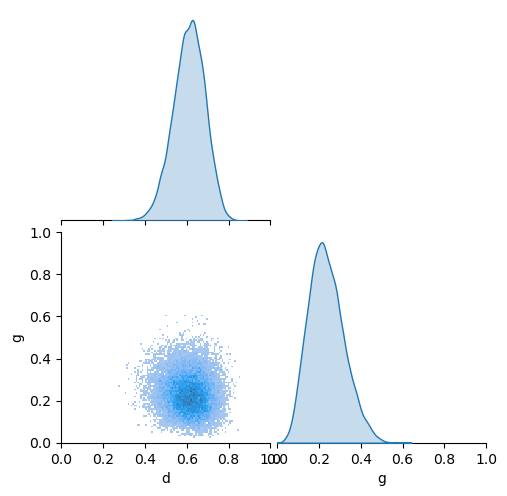

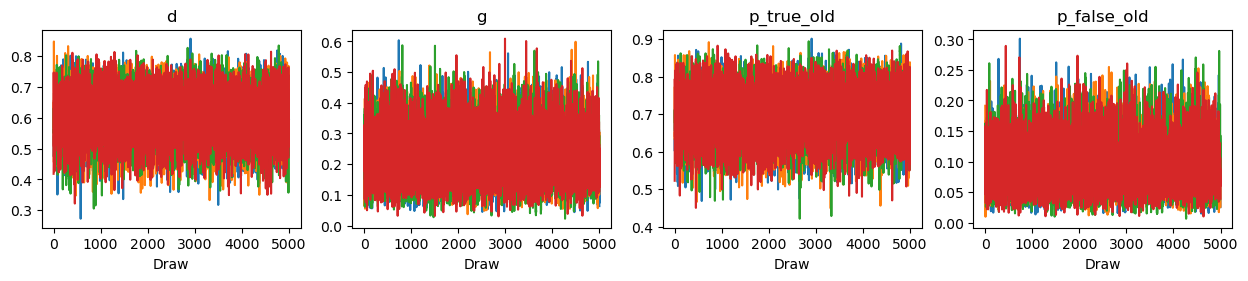

In [232]:
idata_2ht = az.from_cmdstanpy(
    posterior=fit_2ht,
    posterior_predictive="pred_ans",
    observed_data={"old_ans": data_dict["old_ans"],"new_ans": data_dict["new_ans"]},
)
g=sns.pairplot(
    fit_2ht.draws_pd(),vars=["d","g"],
    kind="hist",diag_kind="kde",corner=True
)
g.set(xlim=[0,1])
g.axes[1,0].set_ylim(0,1)
az.plot_trace(idata_2ht)

In [233]:
# from victor's code in questions 3
def ci(values):
    return np.array([float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))])

ci_d_1ht=ci(fit_1ht.stan_variable("d"))
ci_g_1ht=ci(fit_1ht.stan_variable("g"))
print("1-high threshold model:")
print(f"d: mean={fit_1ht.stan_variable('d').mean():.3f} sd={fit_1ht.stan_variable('d').std():.3f} 95% CI: [{ci_d_1ht[0]:.3f}, {ci_d_1ht[1]:.3f}]")
print(f"g: mean={fit_1ht.stan_variable('g').mean():.3f} sd={fit_1ht.stan_variable('g').std():.3f} 95% CI: [{ci_g_1ht[0]:.3f}, {ci_g_1ht[1]:.3f}]")

ci_true_1ht=ci(fit_1ht.stan_variable("p_true_old"))
ci_false_1ht=ci(fit_1ht.stan_variable("p_false_old"))
print(f"Prob. of true positive:  mean={fit_1ht.stan_variable('p_true_old').mean():.3f} sd={fit_1ht.stan_variable('p_true_old').std():.3f} 95% CI: [{ci_true_1ht[0]:.3f}, {ci_true_1ht[1]:.3f}]")
print(f"Prob. of false positive: mean={fit_1ht.stan_variable('p_false_old').mean():.3f} sd={fit_1ht.stan_variable('p_false_old').std():.3f} 95% CI: [{ci_false_1ht[0]:.3f}, {ci_false_1ht[1]:.3f}]")

print("\n"+"="*50+"\n")

ci_d_2ht=ci(fit_2ht.stan_variable("d"))
ci_g_2ht=ci(fit_2ht.stan_variable("g"))
print("2-high threshold model:")
print(f"d: mean={fit_2ht.stan_variable('d').mean():.3f} sd={fit_2ht.stan_variable('d').std():.3f} 95% CI: [{ci_d_2ht[0]:.3f}, {ci_d_2ht[1]:.3f}]")
print(f"g: mean={fit_2ht.stan_variable('g').mean():.3f} sd={fit_2ht.stan_variable('g').std():.3f} 95% CI: [{ci_g_2ht[0]:.3f}, {ci_g_2ht[1]:.3f}]")

ci_true_2ht=ci(fit_2ht.stan_variable("p_true_old"))
ci_false_2ht=ci(fit_2ht.stan_variable("p_false_old"))
print(f"Prob. of true positive:  mean={fit_2ht.stan_variable('p_true_old').mean():.3f} sd={fit_2ht.stan_variable('p_true_old').std():.3f} 95% CI: [{ci_true_2ht[0]:.3f}, {ci_true_2ht[1]:.3f}]")
print(f"Prob. of false positive: mean={fit_2ht.stan_variable('p_false_old').mean():.3f} sd={fit_2ht.stan_variable('p_false_old').std():.3f} 95% CI: [{ci_false_2ht[0]:.3f}, {ci_false_2ht[1]:.3f}]")


1-high threshold model:
d: mean=0.657 sd=0.073 95% CI: [0.506, 0.788]
g: mean=0.099 sd=0.041 95% CI: [0.034, 0.193]
Prob. of true positive:  mean=0.692 sd=0.064 95% CI: [0.561, 0.807]
Prob. of false positive: mean=0.099 sd=0.041 95% CI: [0.034, 0.193]


2-high threshold model:
d: mean=0.609 sd=0.075 95% CI: [0.454, 0.748]
g: mean=0.235 sd=0.084 95% CI: [0.090, 0.418]
Prob. of true positive:  mean=0.702 sd=0.064 95% CI: [0.571, 0.818]
Prob. of false positive: mean=0.092 sd=0.039 95% CI: [0.031, 0.184]


#### Comparison of results:

For the 1HT model (probability `d` of recognizing old items, probability `g` of guessing forgotten or completely new word is old), the posterior mean for `d` is 0.657 and the mean for `g` is 0.099. The transformed quantities of true and false positive probabilities have posterior means of 0.692 and 0.099 respectively. As such, the results of fitting this model suggest that the subject recognized words from the old wordlist more often than not, and predominantly guessed that unfamiliar words weren't in the original wordlist.

The 2HT model (probability `d` of recognizing old items as old, probability `d` of recognizing new items as new, probability `g` of guessing item is old otherwise) gives a posterior mean of 0.609 for `d` and 0.235 for `g`, with the true and false positive probabilities having posterior means of 0.702 and 0.092 respectively. The most notable difference between the model fits is that 2HT predicts slightly lower `d` and higher `g`, with the overall true and false positive probabilities being pretty similar means, standard deviations and confidence intervals. This suggests that the main difference with 2HT is that it treats the low false-positive rate as coming from recognition of words not coming from the original list where 1HT assumes those are all guesses, and as such what it still identifies as guesses are less heavily biased towards negative responses than 1HT does.

More generally though, while these models are different from one another they predict essentially the same behavior: the `d` and `g` values might be different, and the decision-making process being modeled is different, but the probabilities of true and false positives not only have similar means but also have very similar posterior distributions. I feel like because the multinomial tree model being considered here is so simple (it's not even really multinomial since there's only two outcomes per tree, it's just a binomial process), we can't expect many interesting differences between these two models.

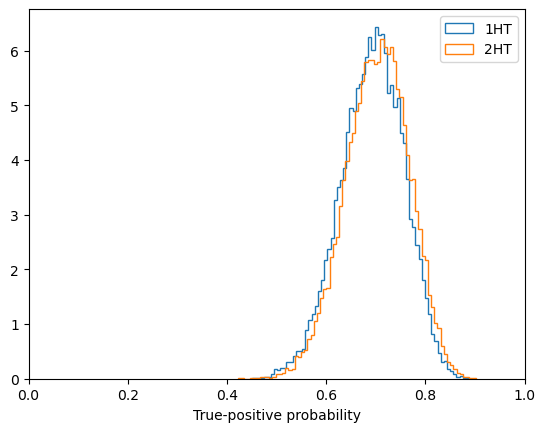

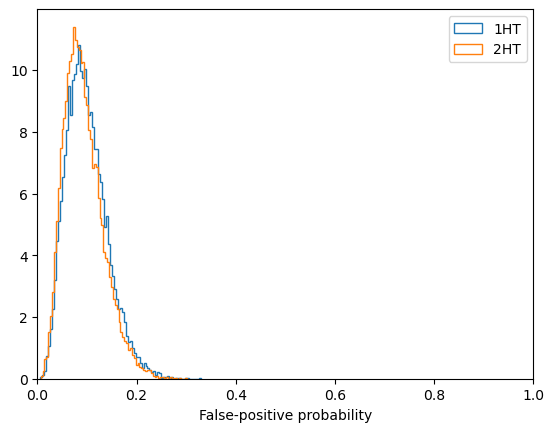

In [234]:
_=plt.hist(fit_1ht.stan_variable("p_true_old"),bins="auto",histtype="step",density=True,label="1HT")
_=plt.hist(fit_2ht.stan_variable("p_true_old"),bins="auto",histtype="step",density=True,label="2HT")
plt.xlim(0,1)
plt.xlabel("True-positive probability")
plt.legend()
plt.figure()
_=plt.hist(fit_1ht.stan_variable("p_false_old"),bins="auto",histtype="step",density=True,label="1HT")
_=plt.hist(fit_2ht.stan_variable("p_false_old"),bins="auto",histtype="step",density=True,label="2HT")
plt.xlim(0,1)
plt.xlabel("False-positive probability")
plt.legend()
